# Exploratory Data Analysis 

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/cleaned_employee_attrition_data.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0


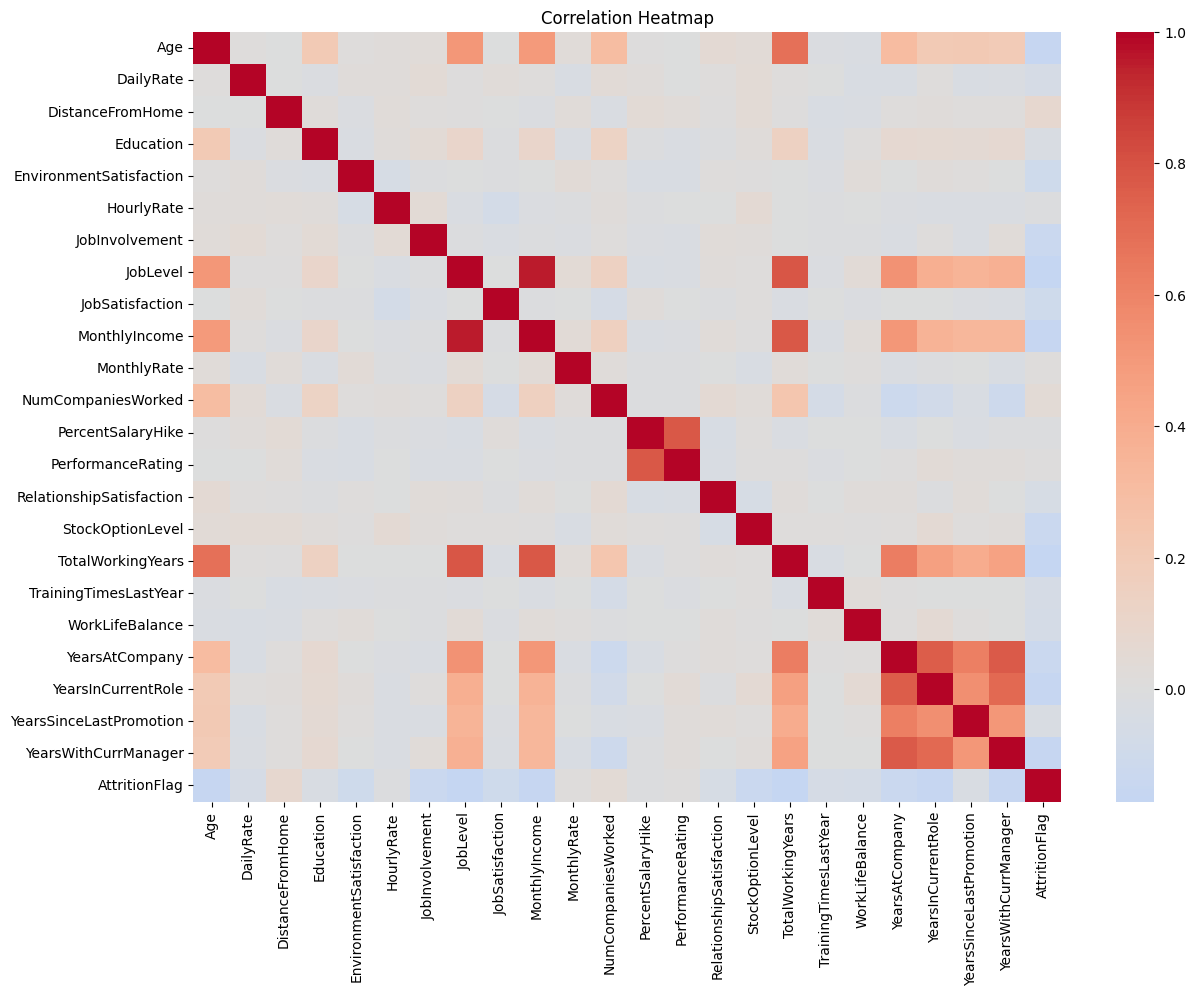

In [5]:
numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

### Executive Insight 

Employee tenure, job level, and compensation are closely related. This indicates these variables may provide overlapping information and should be considered carefully during predictive modeling to avoid multicollinearity. 

Attrition               No        Yes
JobSatisfaction                      
1                77.162630  22.837370
2                83.571429  16.428571
3                83.484163  16.515837
4                88.671024  11.328976


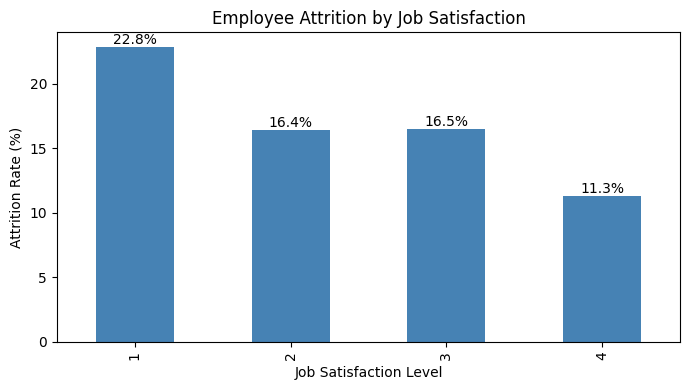

In [15]:
# Job Satisfaction vs Attrition

job_sat = (
    pd.crosstab(
        df['JobSatisfaction'],
        df['Attrition'],
        normalize='index'
    ) * 100
)

print(job_sat)

ax = job_sat['Yes'].plot(
    kind='bar',
    figsize=(7, 4),
    color='steelblue',
)

plt.title('Employee Attrition by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Executive Insight 

Employees with lower job satistfaction exhibit higher attrition rates than employees with higher satisfaction.

This suggests improving employee engagement and satisfaction could reduce turnover, making job satisfaction a priority area for HR initiatives. 

Attrition               No        Yes
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059


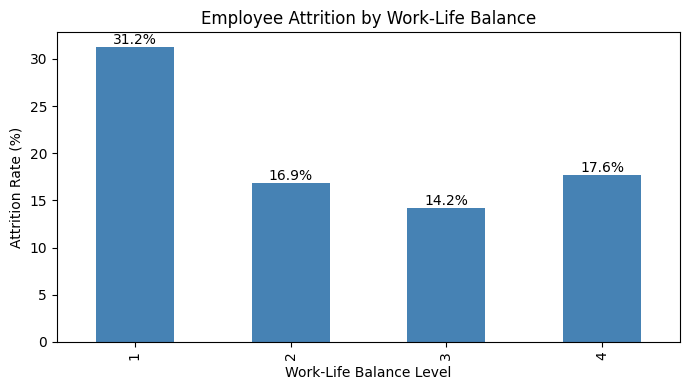

In [16]:
# Work-Life Balance vs Attrition

wlb = (
    pd.crosstab(
        df['WorkLifeBalance'],
        df['Attrition'],
        normalize='index'
    ) * 100
)

print(wlb)

ax =wlb['Yes'].plot(
    kind='bar',
    figsize=(7,4), 
    color='steelblue'

)

plt.title('Employee Attrition by Work-Life Balance')
plt.xlabel('Work-Life Balance Level')
plt.ylabel('Attrition Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Executive Insight 

Employees with a lower work-life balance score exhibit higher attrition rates than employees with higher work-life balance scores. 

Organizations may reduce turnover by promoting flexible scheduling, managing workloads, and encouraging healthy work-life practices. 

Attrition                       No        Yes
EnvironmentSatisfaction                      
1                        74.647887  25.352113
2                        85.017422  14.982578
3                        86.313466  13.686534
4                        86.547085  13.452915


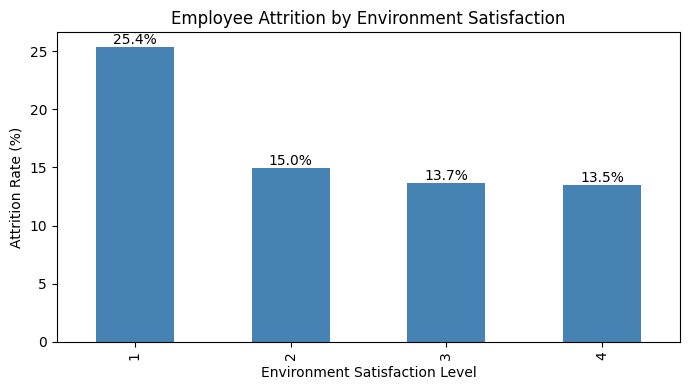

In [17]:
# Enviroment Satisfaction vs Attrition

env = (
    pd.crosstab(
        df['EnvironmentSatisfaction'],
        df['Attrition'],
        normalize='index'
    ) * 100
)

print(env)

ax = env['Yes'].plot(
    kind='bar',
    figsize=(7,4), 
    color='steelblue'
)

plt.title('Employee Attrition by Environment Satisfaction')
plt.xlabel('Environment Satisfaction Level')
plt.ylabel('Attrition Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Executive Insight

Employees who report dissatisfaction with their work enviroment experience substantially higher turnover, suggesting that workplace culture and enviroment play an important role in employee retention. 

Attrition                 No        Yes
BusinessTravel                         
Non-Travel         92.000000   8.000000
Travel_Frequently  75.090253  24.909747
Travel_Rarely      85.043145  14.956855


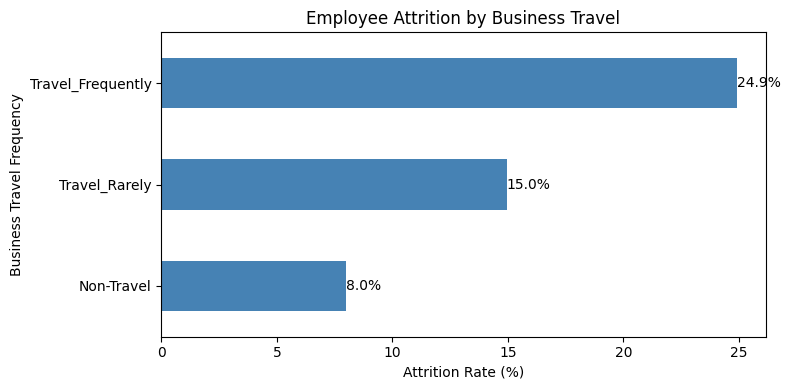

In [18]:
# Travel vs Attrition

travel = (
    pd.crosstab(
        df["BusinessTravel"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

print(travel)

ax = travel["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,4),
    color="steelblue"
)

plt.title("Employee Attrition by Business Travel")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Business Travel Frequency")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Executive Insight

Employees that travel frequently are more likely to leave the organization compared to those who rarely or do not travel.

This suggests that HR should investigate whether travel demands contribute to burnout, work-life imbalance, or job dissatisfaction. 

Attrition             No        Yes
MaritalStatus                      
Divorced       89.908257  10.091743
Married        87.518574  12.481426
Single         74.468085  25.531915


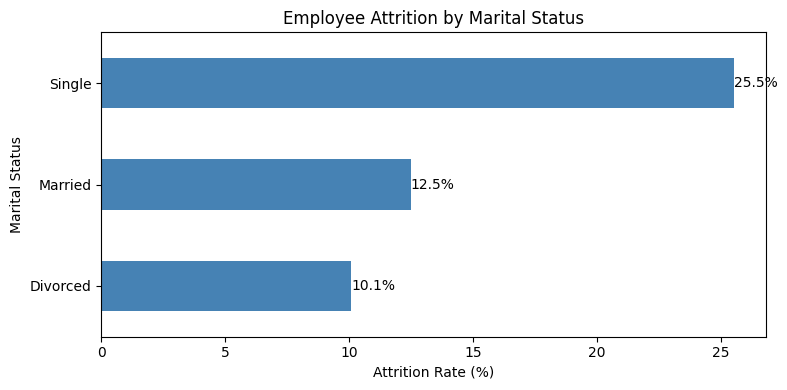

In [19]:
# Marital Status vs Attrition

marital = (
    pd.crosstab(
        df["MaritalStatus"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

print(marital)

ax = marital["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,4),
    color="steelblue"
)

plt.title("Employee Attrition by Marital Status")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Marital Status")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Executive Insight 

Employees that are single exhibit higher attrition rates than those who are married or divored.

While marital status itself is not something organizations should act on, it may reflect broader differences in career stage, mobility, or life priorities. 